# Survey results

## Raw results 

Short version results

In [1]:
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import seaborn as sns
#import plot_likert
import os, glob


In [2]:
from plot_likert import plot_likert

In [3]:
from plot_likert import plot_counts
from plot_likert import colors as plot_colors
from plot_likert import scales, interval

In [4]:
plot_counts

<function plot_likert.plot_likert.plot_counts(counts: pandas.core.frame.DataFrame, scale: List[str], plot_percentage: Optional[bool] = None, colors: List[str] = ['#ffffff00', 'firebrick', 'lightcoral', 'gainsboro', 'cornflowerblue', 'darkblue'], figsize=None, xtick_interval: Optional[int] = None, compute_percentages: bool = False, bar_labels: bool = False, bar_labels_color: Union[str, List[str]] = 'white', center_displacement: int = 0, show_center_line: bool = True, **kwargs) -> matplotlib.axes._axes.Axes>

In [5]:
file_name = "survey_n43.xlsx"

In [6]:
questionaire = "questions.yaml"

In [7]:
df_raw = pd.read_excel(file_name)

In [8]:
df_long = pd.melt(df_raw, id_vars=['ID'], var_name='Question', value_name='Response')

In [9]:
# q_id = pd.read_excel(file_name, sheet_name="Sheet2")

# q_id_long = pd.melt(q_id, var_name='col_idx', value_name='QuestionID')

In [10]:
with open(questionaire, "r") as f:
    dic = yaml.safe_load(f)

print(dic)

{'question': [{'id': 1, 'text': 'Which country do you currently work in?', 'alias': 'country', 'col_start': 6}, {'id': 2, 'text': 'What type of institution or sector best describes your affiliation?', 'alias': 'affiliation_type', 'scale': ['University/Academia', 'Research institute', 'Private consultancy', 'Government agency', 'Industry company', 'Charity / NGO / Not-for-profit organization', 'Other'], 'col_start': 7}, {'id': 3, 'text': 'How many years of experience do you have as an energy system modelling practitioner?', 'alias': 'experience_years', 'scale': ['< 1 year', '1-2 years', '2-5 years', '5-8 years', '8+ years', 'N/A'], 'col_start': 8}, {'id': 4, 'text': 'In your opinion, how does your model output compare to observed trends or reflects the impacts of the following metrics?', 'alias': 'perceived_bias', 'scale': ['Underestimated', 'Somewhat underestimated', 'Accurately represented', 'Somewhat overestimated', 'Overestimated', 'N/A'], 'metrics': ['Profitablity of variable renew

In [11]:
df_questions = {}

for i in range(len(dic["question"]) - 1):
    q_id = dic["question"][i]["id"]
    col_start = dic["question"][i]["col_start"]
    col_end = dic["question"][i + 1]["col_start"]
    df_questions[f"df_q{q_id}"] = df_raw.iloc[:, col_start:col_end].copy()

# Assign to individual variables
# Create standalone variables (df_q1, df_q2, ...) from the dictionary entries.
# Example: df_questions["df_q4"] -> variable df_q4
for name, df in df_questions.items():
    globals()[name] = df  # Assign each DataFrame to the global notebook namespace

# Print summary
for name, df in df_questions.items():
    print(f"{name}: columns {list(df.columns)}")

df_q1: columns ['Which country do you currently work in?']
df_q2: columns ['What type of institution or sector best describes your affiliation?']
df_q3: columns ['How many years of experience do you have as an energy system modelling practitioner?']
df_q4: columns ['Profitablity of variable renewable electricity generation', 'Profitablity of dispatchable electricity generation', 'Need for flexibility (e.g., batteries and thermal storage)', 'Process flexibility (e.g., end use flexibility or plant flexibility)', 'Investments in end-use technologies', 'Central energy solutions over local energy solutions', 'Impact of transmission bottlenecks', 'Investments and electricity flows in transmission lines', 'Investments and transport flows in fluid/gas pipelines', 'Effect of policy instruments', 'Impact of investment decisions during the whole transition', 'Comparable level of detail between competing options']
df_q5: columns ['Elaborate if other, or if you wish to expand on your answers.']
df_

## Functions

In [12]:
def plot_likert_with_nan(df, dic, question_idx, question_title=None, colors=None, center_displacement=None, show_center_line=True):
    """
    Plots a Likert plot with a NaN percentage bar for a given question, with aligned y-ticks and bars, but hides y-axis labels on the right plot.
    Parameters:
        df (pd.DataFrame): DataFrame for the question.
        dic (dict): Dictionary loaded from questions.yaml.
        question_idx (int): Index of the question in dic['question'] (1-based, based on questionaire index).
        question_title (str, optional): Title for the plot. If None, uses dic['question'][question_idx]['text'].
        colors (list, optional): List of colors for the Likert plot bars. If None, uses plot_likert.colors.likert5.
        center_displacement (int, optional): Displacement for the center of the Likert scale. Default is 0.
        show_center_line (bool, optional): Whether to show the center line. Default is True.
    """
    scale = dic['question'][question_idx-1]['scale']
    if question_title is None:
        question_title = dic['question'][question_idx-1]['text']
    nan_pct = df.isna().mean() * 100
    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])
    
    # Likert plot (left)
    ax0 = plt.subplot(gs[0])
    likert_plot = plot_likert(
        df, scale,
        bar_labels=True,
        plot_percentage=True,
        #colors=colors if colors is not None else plot_likert.colors.likert5,
        ax=ax0,
        center_displacement=center_displacement if center_displacement is not None else 0,
        show_center_line=show_center_line,
    )
    for text in ax0.texts:
        try:
            val = float(text.get_text().replace('%',''))
            text.set_text(f"{val:.0f}%")
        except ValueError:
            pass
    ax0.xaxis.set_label_text('Percentage of applicable responses')
    ax0.set_title(question_title)
    
    # Remove legend from ax0
    if hasattr(ax0, 'legend_') and ax0.legend_:
        ax0.legend_.remove()
    
    # NaN percentage bar plot (right)
    ax1 = plt.subplot(gs[1])
    bar_width = None
    if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
        bars = ax0.containers[0]
        if len(bars) > 0:
            bar_width = bars[0].get_height()
    custom_bar_height = bar_width if bar_width is not None else 0.8
    ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
    ax1.set_xlim(0, 100)
    ax1.set_xlabel('% Non applicable')
    for i, v in enumerate(nan_pct.values):
        ax1.text(v + 1, i, f"{v:.0f}%", va='center')
    
    # Align y-ticks and limits with the left plot, but hide labels
    ax1.set_ylim(ax0.get_ylim())
    ax1.set_yticks(ax0.get_yticks())
    ax1.set_yticklabels([''] * len(ax0.get_yticklabels()))
    
    # Add legend to bottom center of the figure
    handles, labels = ax0.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(scale), bbox_to_anchor=(0.5, -0.05), frameon=False)
    plt.tight_layout()
    plt.show()


c:\Users\ife12500\OneDrive - Institutt for Energiteknikk\Documents\GitHub\plot-likert\plot_likert\plot_likert.py:346: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(


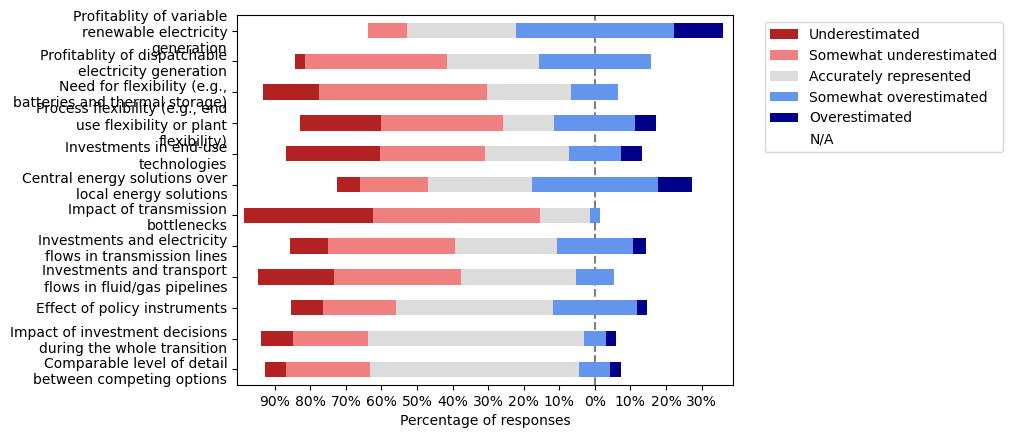

<Figure size 1200x800 with 0 Axes>

In [37]:
scale_q4 = dic["question"][3]["scale"]  # Q4 is index 3 (0-based)

ax = plot_likert(
    df_q4,
    scale_q4,
    bar_labels=False,
    plot_percentage=True
)

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

for text in ax.texts:
    try:
        v = float(text.get_text().replace("%", ""))
        text.set_text(f"{v:.0f}%")
    except ValueError:
        pass

#ax.set_title(dic["question"][3]["text"])
ax.set_xlabel("Percentage of responses")
plt.tight_layout()
plt.show()

## Participant info

Q1 - Q3, & Q8

In [13]:
#df_q1

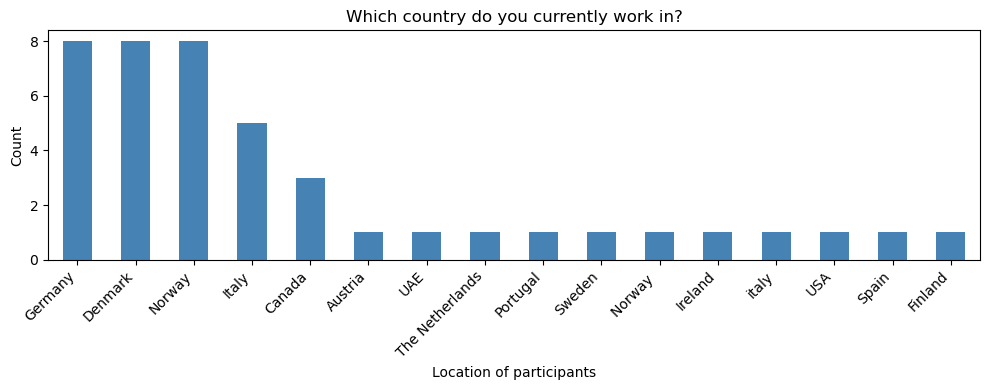

In [14]:
# Frequency bar plot for entries in df_q1
counts = df_q1.iloc[:, 0].value_counts(dropna=False)

ax_q1 = counts.plot(kind="bar", figsize=(10, 4), color="steelblue")
ax_q1.set_title(df_q1.columns[0])
ax_q1.set_xlabel("Location of participants")
ax_q1.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [15]:
#df_q2

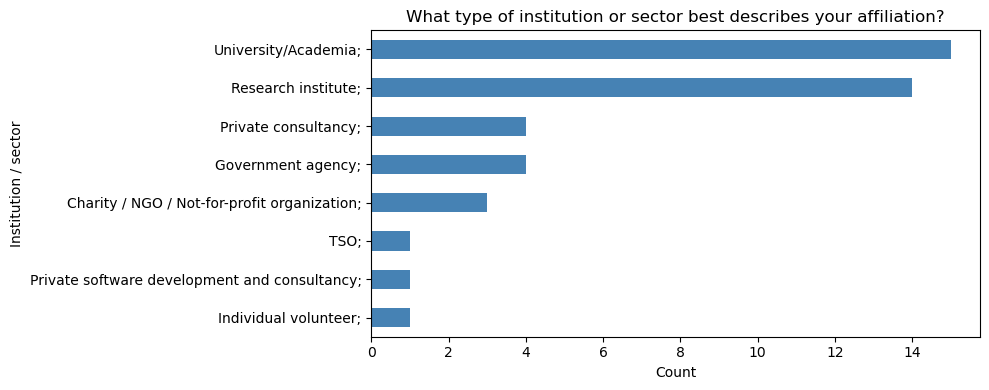

In [16]:
# Ensure df_q2 exists (helps with notebook execution order / linter warnings)
if "df_q2" not in globals():
    df_q2 = df_questions["df_q2"].copy()

# Frequency counts (including missing values)
counts = df_q2.iloc[:, 0].value_counts(dropna=False)
counts.index = counts.index.fillna("No response")

# Horizontal bar chart
ax_q2 = counts.sort_values().plot(kind="barh", figsize=(10, 4), color="steelblue")
ax_q2.set_title(df_q2.columns[0])
ax_q2.set_xlabel("Count")
ax_q2.set_ylabel("Institution / sector")
plt.tight_layout()
plt.show()

In [17]:
#df_q3

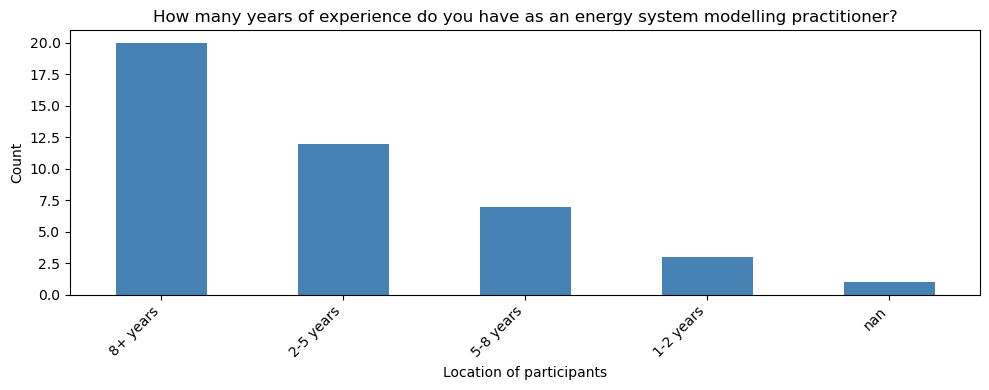

In [18]:
# Frequency bar plot for entries in df_q3
counts = df_q3.iloc[:, 0].value_counts(dropna=False)

ax_q3 = counts.plot(kind="bar", figsize=(10, 4), color="steelblue")
ax_q3.set_title(df_q3.columns[0])
ax_q3.set_xlabel("Location of participants")
ax_q3.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

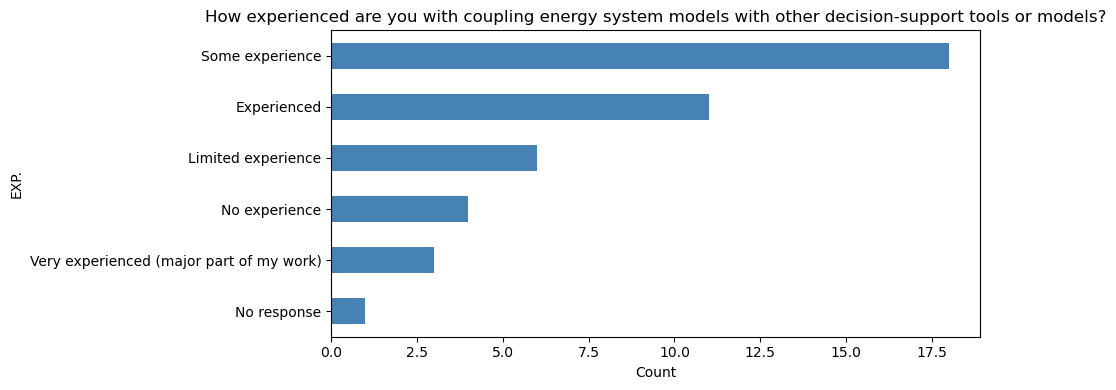

In [19]:
# Ensure df_q2 exists (helps with notebook execution order / linter warnings)
if "df_q8" not in globals():
    df_q8 = df_questions["df_q8"].copy()

# Frequency counts (including missing values)
counts = df_q8.iloc[:, 0].value_counts(dropna=False)
counts.index = counts.index.fillna("No response")

# Horizontal bar chart
ax_q8 = counts.sort_values().plot(kind="barh", figsize=(10, 4), color="steelblue")
ax_q8.set_title(df_q8.columns[0])
ax_q8.set_xlabel("Count")
ax_q8.set_ylabel("EXP.")
plt.tight_layout()
plt.show()

## Perceived biases

Q4

In [20]:
#df_q4

c:\Users\ife12500\OneDrive - Institutt for Energiteknikk\Documents\GitHub\plot-likert\plot_likert\plot_likert.py:346: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(


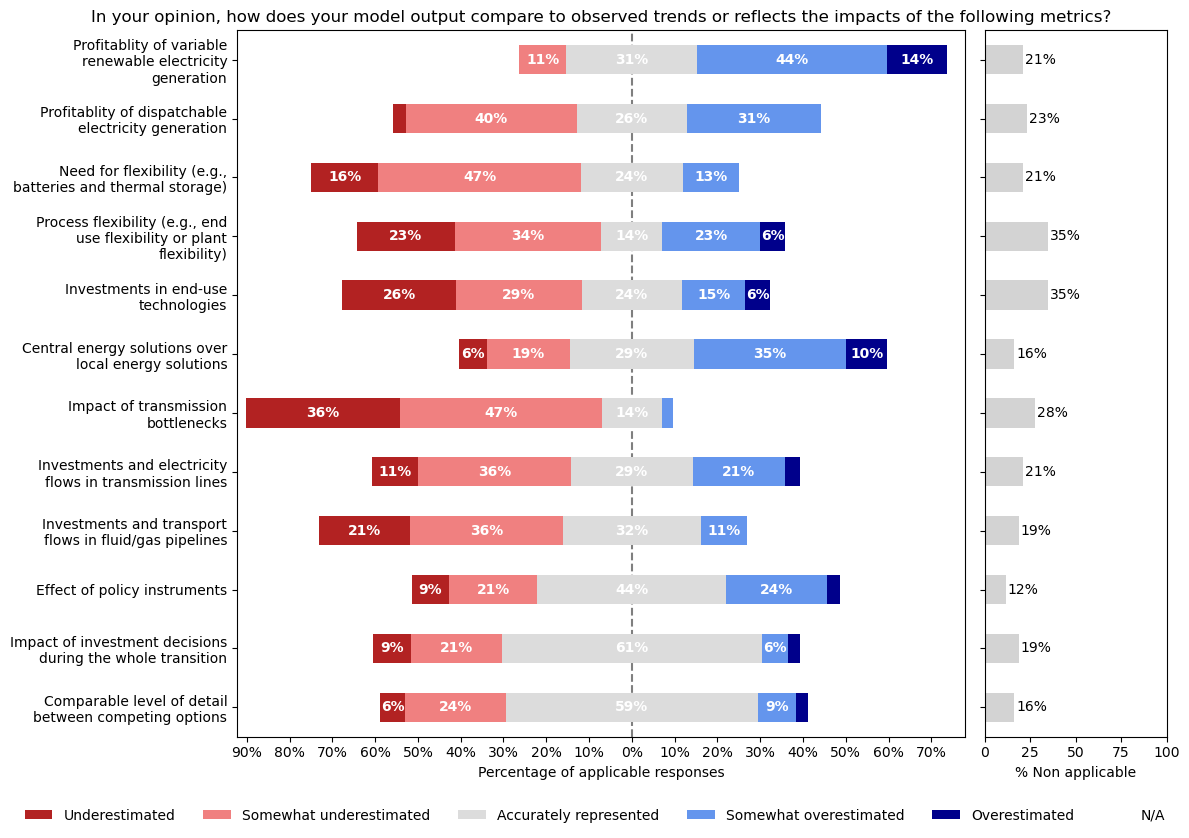

In [34]:
plot_likert_with_nan(df_q4, dic, 4, center_displacement=-1)  # For question 8 (index 7)

### Addressing biases
Q6

In [22]:
#df_q6

c:\Users\ife12500\OneDrive - Institutt for Energiteknikk\Documents\GitHub\plot-likert\plot_likert\plot_likert.py:346: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(


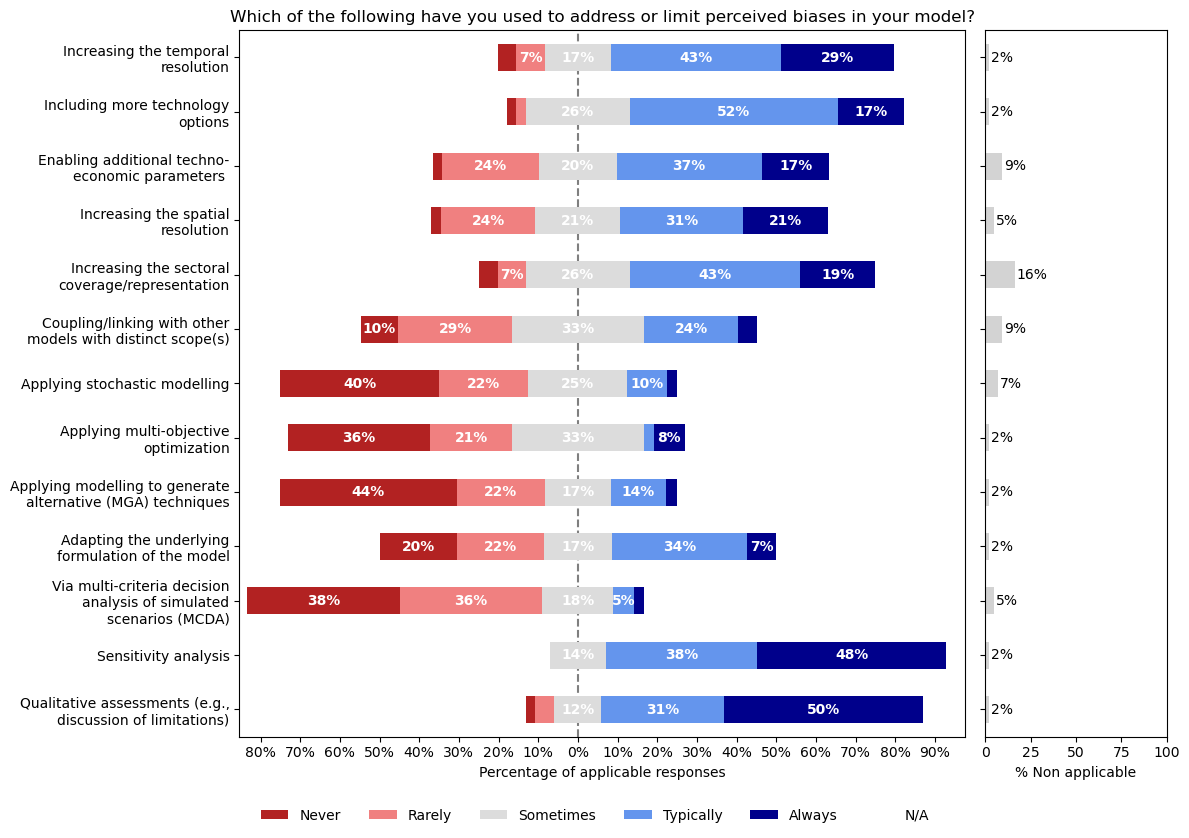

In [23]:
plot_likert_with_nan(df_q6, dic, 6, center_displacement=-1)  # For question 8 (index 7)

## Model coupling
Q8

In [24]:
#df_q9

In [25]:
# import squarify
# import textwrap

# # Count the occurrences of each response in df_q8
# counts = df_q8.iloc[:, 0].value_counts()
# labels = counts.index
# sizes = counts.values
# total = sizes.sum()

# # Wrap text and add percentage to each label
# wrapped_labels = []
# for label, size in zip(labels, sizes):
#     percent = size / total * 100
#     # Wrap label to max 20 chars per line
#     wrapped = "\n".join(textwrap.wrap(label, width=20))
#     wrapped_labels.append(f"{wrapped}\n{size} ({percent:.0f}%)")

# colors = ['#91DCEA', '#64CDCC', '#5FBB68',
#           '#F9D23C', '#F9A729', '#FD6F30']

# plt.figure(figsize=(8, 5))
# squarify.plot(sizes=sizes, color=colors, label=wrapped_labels, alpha=0.8, pad = 0.25)
# plt.title("Q8: Experience with coupling energy system models")
# plt.axis('off')
# plt.show()

c:\Users\ife12500\OneDrive - Institutt for Energiteknikk\Documents\GitHub\plot-likert\plot_likert\plot_likert.py:346: UserWarning: In your data, not all questions have the same number of responses. i.e., different numbers of people answered each question. Therefore, the percentages aren't directly comparable: X% for one question represents a different number of responses than X% for another question, yet they will appear the same in the percentage graph. This may be misleading to your reader.
  warn(


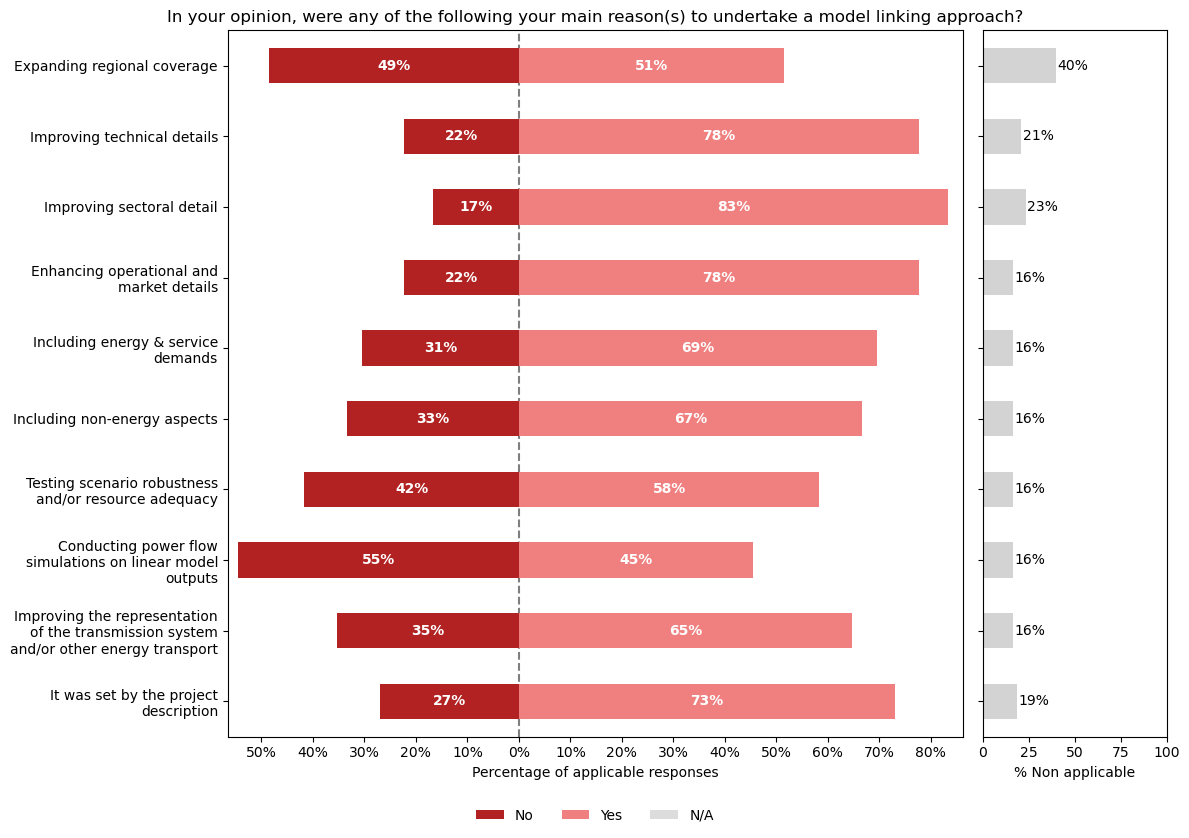

In [35]:
colors_q9= ["#ffffff00", "#FD6F30", "#5FBB68"]

plot_likert_with_nan(df_q9, dic, 9, colors=colors_q9, center_displacement=0)  # For question 9 (index 8)

In [27]:
len([1,2,3,4]) % 2

0

In [28]:
dic['question'][8]['scale']

['No', 'Yes', 'N/A']

AttributeError: 'function' object has no attribute 'plot_likert'

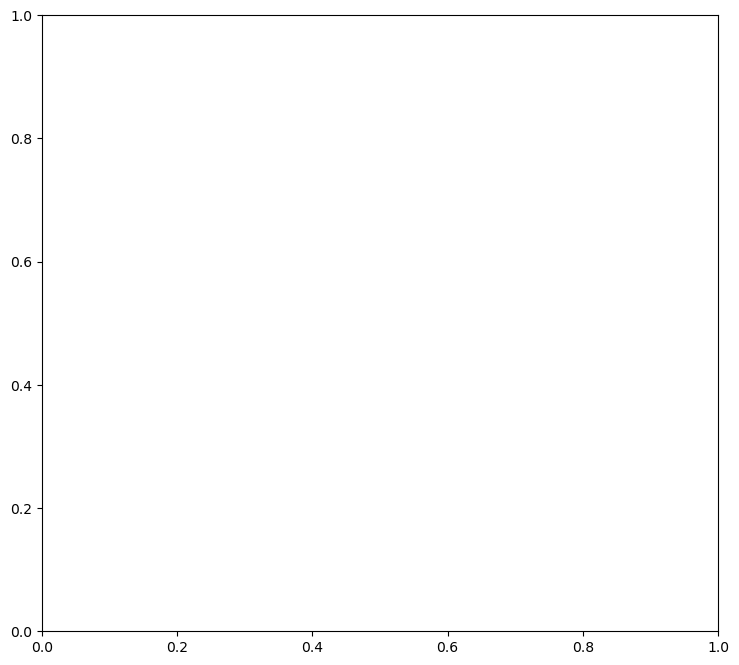

In [29]:
# Calculate percentage of NaN answers per column
nan_pct = df_q9.isna().mean() * 100

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

# Likert plot (left)
ax0 = plt.subplot(gs[0])
likert_plot = plot_likert.plot_likert(
    df_q9, dic['question'][8]['scale'],
    bar_labels=True,
    plot_percentage=True,
    colors= ["#ffffff00", "#FD6F30", "#5FBB68"], # plot_likert.colors.likert5,
    ax=ax0
)
for text in ax0.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
       pass

ax0.xaxis.set_label_text('Percentage of applicable responses');
ax0.set_title("Question 9: Main reasons to undertake model coupling")

# Remove legend from ax0
ax0.legend_.remove()

# NaN percentage bar plot (right)
ax1 = plt.subplot(gs[1])

# Match bar height to the first subplot's bars
bar_width = None
if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
    # Get the width of the first bar in the first subplot
    bars = ax0.containers[0]
    if len(bars) > 0:
        bar_width = bars[0].get_height()

# Option to control bar width
custom_bar_height = bar_width if bar_width is not None else 0.8  # fallback to default if not found

ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
ax1.set_xlim(0, 100)
ax1.set_xlabel('% Non applicable')
#ax1.set_title('Non applicable')
for i, v in enumerate(nan_pct.values):
    ax1.text(v + 1, i, f"{v:.0f}%", va='center')
ax1.invert_yaxis()
ax1.set_yticklabels([''] * len(nan_pct.index))  # Remove y-axis text labels

# Add legend to bottom center of the figure
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(dic['question'][8]['scale']), bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

### Old q3

In [ ]:
df_q3 = df_raw.iloc[:,8:9].copy()
df_q3

In [ ]:
df_q4 = df_raw.iloc[:,9:10].copy()
df_q4

### Q5 - Modelling horizon

In [ ]:
df_q5 = df_raw.iloc[:,10:12].copy()

In [ ]:
q5_scale = ['Never',
            'Rarely',
            'Sometimes',
            'Typically']

In [ ]:
ax = plot_likert.plot_likert(df_q5, q5_scale,
                        bar_labels=True,
                        plot_percentage=True,
                        colors=plot_likert.colors.likert5)

# Set the number of decimals for bar labels
for container in ax.containers:
    for label in container.datavalues:
        pass  # plot_likert does not expose bar label formatting directly

# Workaround: update bar labels if they exist
for text in ax.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
        pass

ax.set_title("a. Typical temporal scope")


plt.show()

### Q6 - Timesteps

In [ ]:
df_q6 = df_raw.iloc[:,12:15].copy()

In [ ]:
q6_scale = ['Never',
            'Rarely',
            'Sometimes',
            'Typically']

In [ ]:
ax = plot_likert.plot_likert(df_q6, q6_scale,
                        bar_labels=True,
                        plot_percentage=True,
                        colors=plot_likert.colors.likert5)

# Set the number of decimals for bar labels
for container in ax.containers:
    for label in container.datavalues:
        pass  # plot_likert does not expose bar label formatting directly

# Workaround: update bar labels if they exist
for text in ax.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
        pass

ax.set_title("b. Typical timesteps")


plt.show()

### Q7 - Sectors

In [ ]:
df_q7 = df_raw.iloc[:,15:19].copy()
#df_q7

In [ ]:
q7_scale = \
    ['Not included',
     'As input assumptions, electricity demands (only)',
     'As input assumptions, energy demands (different carriers)',
     'Energy demands are model outputs']

In [ ]:
ax = plot_likert.plot_likert(df_q7, q7_scale,
                        bar_labels=True,
                        plot_percentage=True,
                        colors=plot_likert.colors.likert5)

# Set the number of decimals for bar labels
for container in ax.containers:
    for label in container.datavalues:
        pass  # plot_likert does not expose bar label formatting directly

# Workaround: update bar labels if they exist
for text in ax.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
        pass

ax.set_title("Question 7: How are energy demands represented in your models?")


plt.show()

In [ ]:
ax = plot_likert.plot_likert(df_q7, q7_scale,
                        bar_labels=True,
                        plot_percentage=True,
                        colors=plot_likert.colors.likert5)

# Set the number of decimals for bar labels
for container in ax.containers:
    for label in container.datavalues:
        pass  # plot_likert does not expose bar label formatting directly

# Workaround: update bar labels if they exist
for text in ax.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
        pass

ax.set_title("Question 7: How are energy demands represented in your models?")

# Move legend to the bottom and make it one row
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol= 2)

plt.show()

## Percieved biases

### Q8 - Biases

In [ ]:
df_q8 = df_raw.iloc[:,19:27].copy() 
#df_q8

In [ ]:
df_q8

In [ ]:
q8_scale = \
    ['Underestimated',
     'Somewhat underestimated',
     'Accurately represented',
     'Somewhat overestimated',
     'Overestimated']

In [ ]:
# Calculate percentage of NaN answers per column
nan_pct = df_q8.isna().mean() * 100

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

# Likert plot (left)
ax0 = plt.subplot(gs[0])
likert_plot = plot_likert.plot_likert(
    df_q8, q8_scale,
    bar_labels=True,
    plot_percentage=True,
    colors=plot_likert.colors.likert5,
    ax=ax0
)
for text in ax0.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
       pass

ax0.xaxis.set_label_text('Percentage of applicable responses');
ax0.set_title("Question 8: Perceived model biases in the following metrics:")

# Remove legend from ax0
ax0.legend_.remove()

# NaN percentage bar plot (right)
ax1 = plt.subplot(gs[1])

# Match bar height to the first subplot's bars
bar_width = None
if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
    # Get the width of the first bar in the first subplot
    bars = ax0.containers[0]
    if len(bars) > 0:
        bar_width = bars[0].get_height()

# Option to control bar width
custom_bar_height = bar_width if bar_width is not None else 0.8  # fallback to default if not found

ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
ax1.set_xlim(0, 100)
ax1.set_xlabel('% Non applicable')
#ax1.set_title('Non applicable')
for i, v in enumerate(nan_pct.values):
    ax1.text(v + 1, i, f"{v:.0f}%", va='center')
ax1.invert_yaxis()
ax1.set_yticklabels([''] * len(nan_pct.index))  # Remove y-axis text labels

# Add legend to bottom center of the figure
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(q8_scale), bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

### Q9 & Q10 - Addressing biases

In [ ]:
df_q9_10 = df_raw.iloc[:,27:38].copy()  # Q9->[:,27:32]  # Q10->[:,32:38]

#df_q9 = df_raw.iloc[:,27:32].copy()
#df_q10 = df_raw.iloc[:,32:38].copy() 

#df_q9
#df_q10

In [ ]:
q9_q10_scale = \
    ['Never',
     'Rarely',
     'Sometimes',
     'Typically']

In [ ]:
# Calculate percentage of NaN answers per column
nan_pct = df_q9_10.isna().mean() * 100

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

# Likert plot (left)
ax0 = plt.subplot(gs[0])
likert_plot = plot_likert.plot_likert(
    df_q9_10, q9_q10_scale,
    bar_labels=True,
    plot_percentage=True,
    colors=plot_likert.colors.likert5,
    ax=ax0
)
for text in ax0.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
       pass

ax0.xaxis.set_label_text('Percentage of applicable responses');
ax0.set_title("Question 9 and 10: Approaches to address perceived model biases")

# Remove legend from ax0
ax0.legend_.remove()

# NaN percentage bar plot (right)
ax1 = plt.subplot(gs[1])

# Match bar height to the first subplot's bars
bar_width = None
if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
    # Get the width of the first bar in the first subplot
    bars = ax0.containers[0]
    if len(bars) > 0:
        bar_width = bars[0].get_height()

# Option to control bar width
custom_bar_height = bar_width if bar_width is not None else 0.8  # fallback to default if not found

ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
ax1.set_xlim(0, 100)
ax1.set_xlabel('% Non applicable')
#ax1.set_title('Non applicable')
for i, v in enumerate(nan_pct.values):
    ax1.text(v + 1, i, f"{v:.0f}%", va='center')
ax1.invert_yaxis()
ax1.set_yticklabels([''] * len(nan_pct.index))  # Remove y-axis text labels

# Add legend to bottom center of the figure
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(q9_q10_scale), bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

## Model coupling

### Q11 - Exp.

In [ ]:
df_q11 = df_raw.iloc[:,38:39].copy()  
#df_q11


In [ ]:
import squarify
import textwrap

# Count the occurrences of each response in df_q11
counts = df_q11.iloc[:, 0].value_counts()
labels = counts.index
sizes = counts.values
total = sizes.sum()

# Wrap text and add percentage to each label
wrapped_labels = []
for label, size in zip(labels, sizes):
    percent = size / total * 100
    # Wrap label to max 20 chars per line
    wrapped = "\n".join(textwrap.wrap(label, width=20))
    wrapped_labels.append(f"{wrapped}\n{size} ({percent:.0f}%)")

colors = ['#91DCEA', '#64CDCC', '#5FBB68',
          '#F9D23C', '#F9A729', '#FD6F30']

plt.figure(figsize=(8, 5))
squarify.plot(sizes=sizes, color=colors, label=wrapped_labels, alpha=0.8, pad = 0.25)
plt.title("Q11: Experience with coupling energy system models")
plt.axis('off')
plt.show()

### Q12 & Q13 - Reasons for linking

In [ ]:
df_q12 = df_raw.iloc[:,39:46].copy() 
#df_q12

In [ ]:
q12_scale  = \
    ['No',
     'Yes']
    #, NaN']

In [ ]:
# Calculate percentage of NaN answers per column
nan_pct = df_q12.isna().mean() * 100

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

# Likert plot (left)
ax0 = plt.subplot(gs[0])
likert_plot = plot_likert.plot_likert(
    df_q12, q12_scale,
    bar_labels=True,
    plot_percentage=True,
    colors= ["#ffffff00", "#FD6F30", "#5FBB68"], # plot_likert.colors.likert5,
    ax=ax0
)
for text in ax0.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
       pass

ax0.xaxis.set_label_text('Percentage of applicable responses');
ax0.set_title("Question 12: Main reasons to undertake model coupling")

# Remove legend from ax0
ax0.legend_.remove()

# NaN percentage bar plot (right)
ax1 = plt.subplot(gs[1])

# Match bar height to the first subplot's bars
bar_width = None
if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
    # Get the width of the first bar in the first subplot
    bars = ax0.containers[0]
    if len(bars) > 0:
        bar_width = bars[0].get_height()

# Option to control bar width
custom_bar_height = bar_width if bar_width is not None else 0.8  # fallback to default if not found

ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
ax1.set_xlim(0, 100)
ax1.set_xlabel('% Non applicable')
#ax1.set_title('Non applicable')
for i, v in enumerate(nan_pct.values):
    ax1.text(v + 1, i, f"{v:.0f}%", va='center')
ax1.invert_yaxis()
ax1.set_yticklabels([''] * len(nan_pct.index))  # Remove y-axis text labels

# Add legend to bottom center of the figure
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(q12_scale), bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

In [ ]:
# Long text reply
df_q13 = df_raw.iloc[:,46:47].copy()  
#df_q13

### Q14 & Q15 - Satisfaction

In [ ]:
df_q14 = df_raw.iloc[:,47:48].copy() 
#df_q14

In [ ]:
df_q14

In [ ]:
q14_scale  = \
    ['Very dissatisfied',
    'Somewhat dissatisfied',
    'Neither satisfied nor dissatisfied',
    'Somewhat satisfied',
    'Very satisfied' ]
    #, NaN']

In [ ]:
# Calculate percentage of NaN answers per column
nan_pct = df_q14.isna().mean() * 100

fig = plt.figure(figsize=(10, 3))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

# Likert plot (left)
ax0 = plt.subplot(gs[0])
likert_plot = plot_likert.plot_likert(
    df_q14, q14_scale,
    bar_labels=True,
    plot_percentage=True,
    #colors= ["#ffffff00", "#FD6F30", "#5FBB68"], # plot_likert.colors.likert5,
    ax=ax0
)
for text in ax0.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
       pass

ax0.xaxis.set_label_text('Percentage of applicable responses');
ax0.set_title("Satisfaction with previous model coupling exp.")

# Remove legend from ax0
ax0.legend_.remove()

# NaN percentage bar plot (right)
ax1 = plt.subplot(gs[1])

# Match bar height to the first subplot's bars
bar_width = None
if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
    # Get the width of the first bar in the first subplot
    bars = ax0.containers[0]
    if len(bars) > 0:
        bar_width = bars[0].get_height()

# Option to control bar width
custom_bar_height = bar_width if bar_width is not None else 0.8  # fallback to default if not found

ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
ax1.set_xlim(0, 100)
ax1.set_xlabel('% Non applicable')
#ax1.set_title('Non applicable')
for i, v in enumerate(nan_pct.values):
    ax1.text(v + 1, i, f"{v:.0f}%", va='center')
ax1.invert_yaxis()
ax1.set_yticklabels([''] * len(nan_pct.index))  # Remove y-axis text labels

# Add legend to bottom center of the figure
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(q12_scale), bbox_to_anchor=(0.5, -0.25)) #ncol=len(q12_scale)

plt.tight_layout()
plt.show()

In [ ]:
# Long text reply
df_q15 = df_raw.iloc[:,48:49].copy()  
df_q15

### Q16 - Harmonized inputs

In [ ]:
df_q16 = df_raw.iloc[:,49:52].copy() 
#df_q16

In [ ]:
q16_scale = [
    'Not considered',
    'Somewhat aligned',
    'Fully aligned'
]

In [ ]:
# Calculate percentage of NaN answers per column
nan_pct = df_q16.isna().mean() * 100

fig = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

# Likert plot (left)
ax0 = plt.subplot(gs[0])
likert_plot = plot_likert.plot_likert(
    df_q16, q16_scale,
    bar_labels=True,
    plot_percentage=True,
    colors= ["#ffffff00", "#FD6F30", "#CFC5C0" , "#5FBB68"], # plot_likert.colors.likert5,
    ax=ax0
)
for text in ax0.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
       pass

ax0.xaxis.set_label_text('Percentage of applicable responses');
ax0.set_title("Alignment of models during coupling")

# Remove legend from ax0
ax0.legend_.remove()

# NaN percentage bar plot (right)
ax1 = plt.subplot(gs[1])

# Match bar height to the first subplot's bars
bar_width = None
if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
    # Get the width of the first bar in the first subplot
    bars = ax0.containers[0]
    if len(bars) > 0:
        bar_width = bars[0].get_height()

# Option to control bar width
custom_bar_height = bar_width if bar_width is not None else 0.8  # fallback to default if not found

ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
ax1.set_xlim(0, 100)
ax1.set_xlabel('% Non applicable')
#ax1.set_title('Non applicable')
for i, v in enumerate(nan_pct.values):
    ax1.text(v + 1, i, f"{v:.0f}%", va='center')
ax1.invert_yaxis()
ax1.set_yticklabels([''] * len(nan_pct.index))  # Remove y-axis text labels

# Add legend to bottom center of the figure
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(q16_scale), bbox_to_anchor=(0.5, -0.105)) #ncol=len(q12_scale)

plt.tight_layout()
plt.show()

## Non-energy perspectives

### Q17 & Q18 - Non-energy perspectives

In [ ]:
df_q17 = df_raw.iloc[:,52:59].copy() 
#df_q17

In [ ]:
df_q17.iloc[3]

In [ ]:
q17_scale = [
    'Never',
    'Impacts assessed in post processing',
    'Considered via model linking',
    'Integrated within the model']

In [ ]:
# Calculate percentage of NaN answers per column
nan_pct = df_q17.isna().mean() * 100

fig = plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

# Likert plot (left)
ax0 = plt.subplot(gs[0])
likert_plot = plot_likert.plot_likert(
    df_q17, q17_scale,
    bar_labels=True,
    plot_percentage=True,
    colors= plot_likert.colors.likert5,
    ax=ax0
)
for text in ax0.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
       pass

ax0.xaxis.set_label_text('Percentage of applicable responses');
ax0.set_title("Non-energy perspectives and how these are included")

# Remove legend from ax0
ax0.legend_.remove()

# NaN percentage bar plot (right)
ax1 = plt.subplot(gs[1])

# Match bar height to the first subplot's bars
bar_width = None
if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
    # Get the width of the first bar in the first subplot
    bars = ax0.containers[0]
    if len(bars) > 0:
        bar_width = bars[0].get_height()

# Option to control bar width
custom_bar_height = bar_width if bar_width is not None else 0.8  # fallback to default if not found

ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
ax1.set_xlim(0, 100)
ax1.set_xlabel('% Non applicable')
#ax1.set_title('Non applicable')
for i, v in enumerate(nan_pct.values):
    ax1.text(v + 1, i, f"{v:.0f}%", va='center')
ax1.invert_yaxis()
ax1.set_yticklabels([''] * len(nan_pct.index))  # Remove y-axis text labels

# Add legend to bottom center of the figure
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(q17_scale), bbox_to_anchor=(0.5, -0.05)) #ncol=len(q12_scale)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate percentage of NaN answers per column
nan_pct = df_q17.isna().mean() * 100

fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])

# Likert plot (left)
ax0 = plt.subplot(gs[0])
likert_plot = plot_likert.plot_likert(
    df_q17, q17_scale,
    bar_labels=True,
    plot_percentage=True,
    colors= plot_likert.colors.likert5,
    ax=ax0
)
for text in ax0.texts:
    try:
        val = float(text.get_text().replace('%',''))
        text.set_text(f"{val:.0f}%")
    except ValueError:
       pass

ax0.xaxis.set_label_text('Percentage of applicable responses');
ax0.set_title("Non-energy perspectives and how these are included")

# Remove legend from ax0
ax0.legend_.remove()

# Add legend to bottom center of the figure
handles, labels = ax0.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(q17_scale), bbox_to_anchor=(0.5, -0.05)) #ncol=len(q12_scale)

plt.tight_layout()
plt.show()

In [ ]:
# Long text reply
df_q18 = df_raw.iloc[:,59:60].copy()  
df_q18

In [ ]:
def plot_likert_with_nan_no_labels(df, dic, question_idx, question_title=None):
    """
    Plots a Likert plot with a NaN percentage bar for a given question, with aligned y-ticks and bars, but hides y-axis labels on the right plot.
    Parameters:
        df (pd.DataFrame): DataFrame for the question.
        dic (dict): Dictionary loaded from questions.yaml.
        question_idx (int): Index of the question in dic['question'] (1-based).
        question_title (str, optional): Title for the plot. If None, uses dic['question'][question_idx]['text'].
    """
    scale = dic['question'][question_idx-1]['scale']
    if question_title is None:
        question_title = dic['question'][question_idx-1]['text']
    nan_pct = df.isna().mean() * 100
    fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(1, 2, width_ratios=[4, 1])
    # Likert plot (left)
    ax0 = plt.subplot(gs[0])
    likert_plot = plot_likert.plot_likert(
        df, scale,
        bar_labels=True,
        plot_percentage=True,
        colors=plot_likert.colors.likert5,
        ax=ax0
    )
    for text in ax0.texts:
        try:
            val = float(text.get_text().replace('%',''))
            text.set_text(f"{val:.0f}%")
        except ValueError:
            pass
    ax0.xaxis.set_label_text('Percentage of applicable responses')
    ax0.set_title(question_title)
    # Remove legend from ax0
    if hasattr(ax0, 'legend_') and ax0.legend_:
        ax0.legend_.remove()
    # NaN percentage bar plot (right)
    ax1 = plt.subplot(gs[1])
    bar_width = None
    if hasattr(ax0, 'containers') and len(ax0.containers) > 0:
        bars = ax0.containers[0]
        if len(bars) > 0:
            bar_width = bars[0].get_height()
    custom_bar_height = bar_width if bar_width is not None else 0.8
    ax1.barh(nan_pct.index, nan_pct.values, color='lightgray', height=custom_bar_height)
    ax1.set_xlim(0, 100)
    ax1.set_xlabel('% Non applicable')
    for i, v in enumerate(nan_pct.values):
        ax1.text(v + 1, i, f"{v:.0f}%", va='center')
    # Align y-ticks and limits with the left plot, but hide labels
    ax1.set_ylim(ax0.get_ylim())
    ax1.set_yticks(ax0.get_yticks())
    ax1.set_yticklabels([''] * len(ax0.get_yticklabels()))
    # Add legend to bottom center of the figure
    handles, labels = ax0.get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(scale), bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    plt.show()

In [ ]:
plot_likert_with_nan_no_labels(df_q4, dic, 4)